# LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# EDA

In [2]:
df = pd.read_csv('ford.csv')
df_cleaned = df.copy()

In [3]:
df_cleaned.shape

(17966, 9)

In [4]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [5]:
df_cleaned.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [6]:
df_cleaned.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [7]:
df_cleaned.duplicated().sum()

np.int64(154)

In [8]:
df_cleaned.drop_duplicates(inplace= True)

In [9]:
df_cleaned.shape

(17812, 9)

In [10]:
df_cleaned.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [11]:
int_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'year']
cat_cols = ['model', 'transmission', 'fuelType']

In [12]:
df_cleaned['year'].value_counts()

year
2017    4854
2018    3982
2019    3152
2016    2314
2015    1355
2014     799
2013     606
2020     252
2012     115
2011      94
2009      91
2010      67
2008      56
2007      32
2005      16
2006      13
2004       4
2002       3
2003       3
1998       1
1996       1
2000       1
2060       1
Name: count, dtype: int64

In [13]:
df_cleaned = df_cleaned[df_cleaned['year'] < 2026]

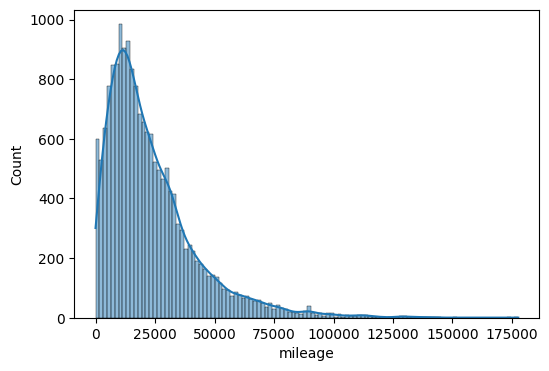

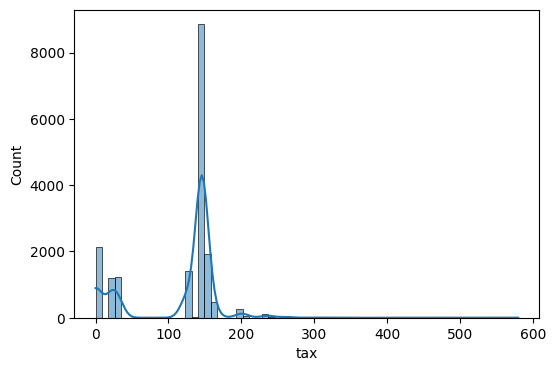

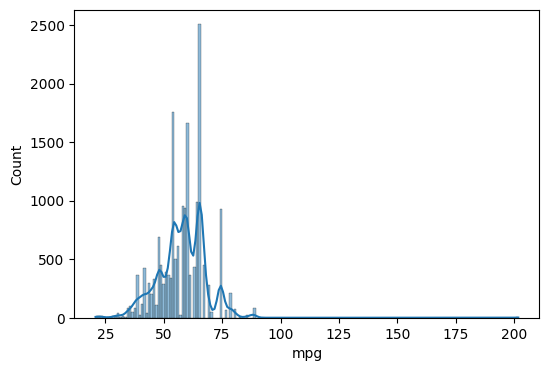

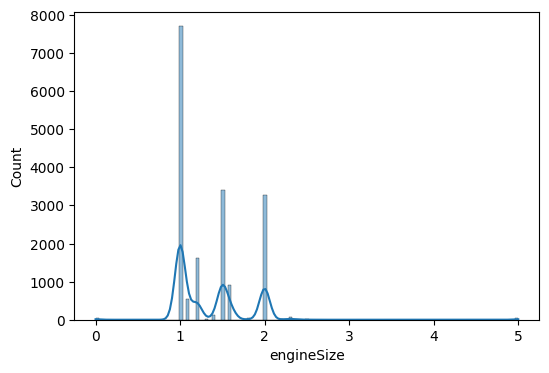

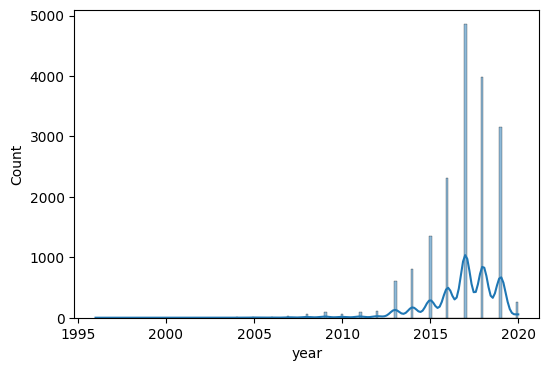

In [14]:
for col in int_cols:
    plt.figure(figsize = (6,4))
    sns.histplot(data = df_cleaned, x = col, kde = True)

In [15]:
df_cleaned['engineSize'] = df_cleaned['engineSize'].replace(0, df_cleaned['engineSize'].mode()[0])

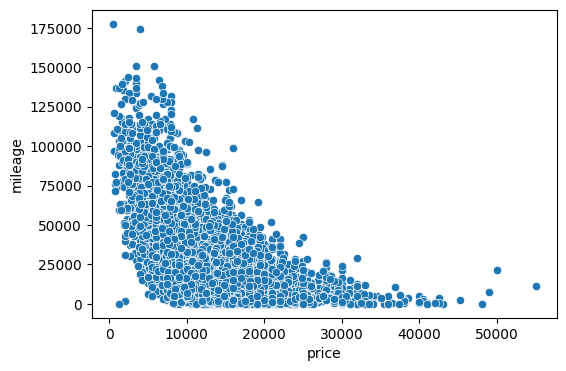

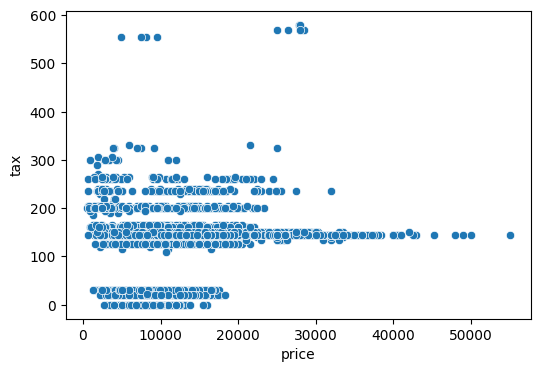

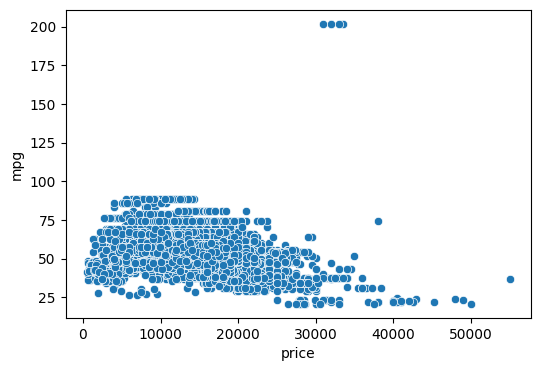

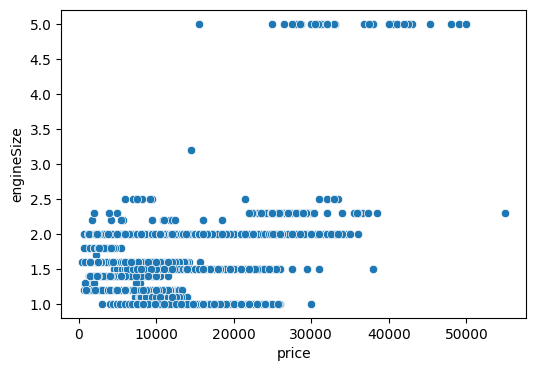

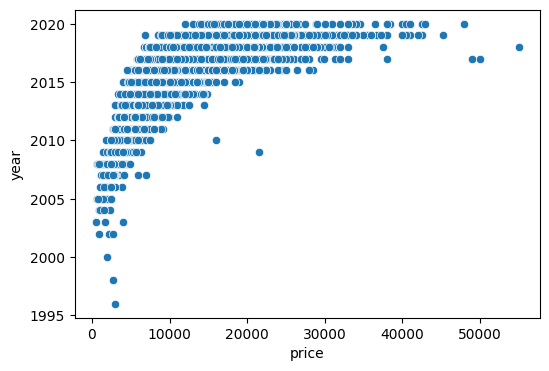

In [16]:
for col in int_cols:
    plt.figure(figsize = (6,4))
    sns.scatterplot(data = df_cleaned, x = 'price', y = col)

<Axes: >

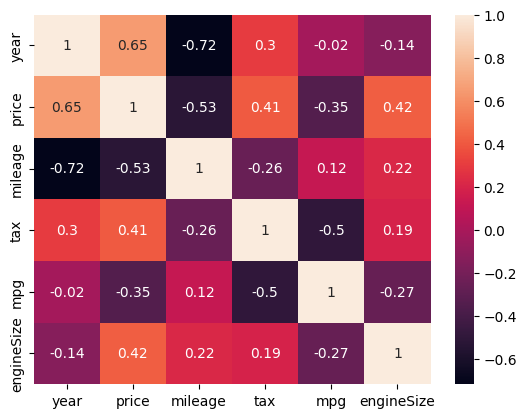

In [17]:
sns.heatmap(df_cleaned.corr(numeric_only=True), annot=True)

In [18]:
df_cleaned.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


### Label Encoding

In [19]:
df_cleaned = pd.get_dummies(df_cleaned, drop_first= True)

In [20]:
df_cleaned.corr()['price'].sort_values()

mileage                        -0.530433
mpg                            -0.346401
model_ Fiesta                  -0.333003
transmission_Manual            -0.258430
fuelType_Petrol                -0.204498
model_ KA                      -0.157717
model_ Ka+                     -0.131138
model_ C-MAX                   -0.088144
model_ Fusion                  -0.061502
model_ Grand C-MAX             -0.034762
model_ Streetka                -0.023148
model_ Escort                  -0.014666
model_Focus                    -0.006283
model_ Mondeo                  -0.000397
model_ Transit Tourneo          0.000285
fuelType_Other                  0.002421
model_ Ranger                   0.003520
fuelType_Electric               0.007759
model_ EcoSport                 0.010942
model_ Tourneo Connect          0.014266
model_ Grand Tourneo Connect    0.029857
fuelType_Hybrid                 0.073356
model_ Focus                    0.112519
model_ Tourneo Custom           0.117140
model_ Puma     

In [21]:
cat_features = ['model_ C-MAX', 'model_ EcoSport', 'model_ Edge', 'model_ Escort', 'model_ Fiesta', 'model_ Focus', 'model_ Fusion', 'model_ Galaxy', 'model_ Grand C-MAX', 'model_ Grand Tourneo Connect', 'model_ KA', 'model_ Ka+', 'model_ Kuga', 'model_ Mondeo', 'model_ Mustang', 'model_ Puma', 'model_ Ranger', 'model_ S-MAX', 'model_ Streetka', 'model_ Tourneo Connect', 'model_ Tourneo Custom', 'model_ Transit Tourneo', 'model_Focus', 'transmission_Manual', 'transmission_Semi-Auto', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol']

In [22]:
df_cleaned[cat_features] = df_cleaned[cat_features].astype(int)

In [23]:
df_cleaned

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,15944,150,57.7,1.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2018,14000,9083,150,57.7,1.0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,13000,12456,150,57.7,1.0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,17500,10460,145,40.3,1.5,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,2019,16500,1482,145,48.7,1.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,8999,16700,150,47.1,1.4,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2014,7499,40700,30,57.7,1.0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,2015,9999,7010,20,67.3,1.6,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,2018,8299,5007,145,57.7,1.2,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [24]:
alpha = 0.05
chi2_result = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['price'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    if p_val < alpha:
        decision = 'Reject Null (Keep Feature)'
    else:
        decision = 'Accept Null (Drop Feature)'

    chi2_result[col] = {
        'contingency' : contingency,
        'p_value': p_val,
        'decision' : decision
    }

chi2_df = pd.DataFrame(chi2_result).T

In [25]:
chi2_df.sort_values(by = 'p_value')

,contingency,p_value,decision
model_ Mustang,price 495 675 694 795 85...,0.0,Reject Null (Keep Feature)
model_ Edge,price 495 675 694 795 850 ...,0.0,Reject Null (Keep Feature)
model_ Fusion,price 495 675 694 795 850...,0.0,Reject Null (Keep Feature)
model_ Streetka,price 495 675 694 795 8...,0.0,Reject Null (Keep Feature)
model_ KA,price 495 675 694 795 850 ...,0.0,Reject Null (Keep Feature)
model_ Puma,price 495 675 694 795 850 ...,0.0,Reject Null (Keep Feature)
fuelType_Hybrid,price 495 675 694 795 8...,0.0,Reject Null (Keep Feature)
model_ Galaxy,price 495 675 694 795 850...,0.0,Reject Null (Keep Feature)
model_ Tourneo Custom,price 495 675 694 79...,0.0,Reject Null (Keep Feature)
model_ Fiesta,price 495 675 694 795 850...,0.0,Reject Null (Keep Feature)


In [26]:
final_df = df_cleaned[['year', 'mileage', 'tax', 'mpg', 'engineSize', 'model_ Mustang', 'model_ Edge', 'model_ Fusion', 'model_ Streetka', 'model_ KA', 'model_ Puma', 'fuelType_Hybrid', 'model_ Galaxy', 'model_ Tourneo Custom', 'model_ Fiesta', 'model_ Kuga', 'model_ S-MAX', 'transmission_Manual', 'fuelType_Petrol', 'fuelType_Electric', 'model_ Focus', 'transmission_Semi-Auto', 'model_ Mondeo', 'model_ Ka+', 'price']]

In [27]:
final_df

,year,mileage,tax,mpg,engineSize,model_ Mustang,model_ Edge,model_ Fusion,model_ Streetka,model_ KA,...,model_ Kuga,model_ S-MAX,transmission_Manual,fuelType_Petrol,fuelType_Electric,model_ Focus,transmission_Semi-Auto,model_ Mondeo,model_ Ka+,price
0,2017,15944,150,57.7,1.0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,12000
1,2018,9083,150,57.7,1.0,0,0,0,0,0,...,0,0,1,1,0,1,0,0,0,14000
2,2017,12456,150,57.7,1.0,0,0,0,0,0,...,0,0,1,1,0,1,0,0,0,13000
3,2019,10460,145,40.3,1.5,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,17500
4,2019,1482,145,48.7,1.0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,16500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47.1,1.4,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,8999
17962,2014,40700,30,57.7,1.0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,7499
17963,2015,7010,20,67.3,1.6,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,9999
17964,2018,5007,145,57.7,1.2,0,0,0,0,1,...,0,0,1,1,0,0,0,0,0,8299


#  MODELS

## Base Models

In [28]:
y = final_df['price']
x = final_df.drop('price', axis = 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [29]:
base_models_dic = {'lr_base_model': LinearRegression(), 'knn_base_model': KNeighborsRegressor(), 'dt_base_model': DecisionTreeRegressor(random_state = 42), 'rf_base_model': RandomForestRegressor(n_estimators = 100, random_state = 100)}
base_models_r2 = {}
base_models_adjusted_r2 = {}

In [30]:
n = x_test.shape[0]
p = x_test.shape[1]

for name, model in base_models_dic.items():
    if name in ['lr_base_model', 'knn_base_model']:
        model.fit(x_train_scaled, y_train)
        y_predict = model.predict(x_test_scaled)
        base_models_r2[name] = r2_score(y_test, y_predict)
        base_models_adjusted_r2[name] = 1 - ((1 - base_models_r2[name])*(n - 1) / (n - p - 1))
    else:
        model.fit(x_train, y_train)
        y_predict = model.predict(x_test)
        base_models_r2[name] = r2_score(y_test, y_predict)
        base_models_adjusted_r2[name] = 1 - ((1 - base_models_r2[name])*(n-1) / (n - p - 1))

In [31]:
base_models_df = pd.DataFrame({
    'r2': base_models_r2,
    'adjusted_r2': base_models_adjusted_r2,
}).sort_values(by = 'r2', ascending=False)

In [32]:
base_models_df

,r2,adjusted_r2
rf_base_model,0.932486,0.932028
knn_base_model,0.930848,0.930379
dt_base_model,0.887250,0.886485
lr_base_model,0.857205,0.856236


## rf model tuning

In [33]:
from sklearn.model_selection import RandomizedSearchCV

classifier = RandomizedSearchCV(
    estimator = RandomForestRegressor(),
    n_iter = 20,
    param_distributions= {'n_estimators': [100, 200], 'max_depth': [6, 10, None], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2], 'max_features': ['sqrt']},
    cv = 5,
    random_state = 42
)
classifier.fit(x_train, y_train)
tuned_rf_model = classifier.best_estimator_
y_predict = tuned_rf_model.predict(x_test)
tuned_rf_model_r2 = r2_score(y_test, y_predict)
tuned_rf_model_adjusted_r2 = 1 - ((1 - tuned_rf_model_r2)*(n - 1) / (n - p - 1))

In [36]:
print(tuned_rf_model_r2)
print(tuned_rf_model_adjusted_r2)

0.9385112981895817
0.9380941899805794


# Since we got rf model stabled and too good performance, i don't think so i need to try tuning and ensemble learning

In [42]:
import joblib

joblib.dump(tuned_rf_model, 'ford_model_app.pkl')

['ford_model_app.pkl']